#Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates #date formatter
import numpy as np

#Load Dataset (June 2021)

In [ ]:
df = pd.read_excel("/content/Raw Data June.xlsx")
df.head()

,June,Unnamed: 1,For PR Calculation,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,For TA Calculation,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,227.398827,NaN,...,39.719467,NaN,NaN,NaN,423.083333,422.116667,422.466667,0.766667,1.35,1.433333
1,Date and Time,NaN,FPE.Meteo01.sensor_row_a17.Irradiation,FPE.Meteo01.sensor_row_b22.Irradiation,FPE.Meteo01.sensor_row_b24.Irradiation,FPE.Meteo02.sensor_row_a05.Irradiation,FPE.Meteo02.sensor_row_a06.Irradiation,FPE.Meteo02.sensor_row_b11.Irradiation,NaN,Power.Analyzer_Schneider_ION.Active Power Total,...,NaN,Inverter.01.AC_active_power,Inverter.02.AC_active_power,Inverter.03.AC_active_power,When Max Solar Irradiance is higher than 1,NaN,NaN,Inverters down time,NaN,NaN
2,[dd.mm.YYYY],[HH:MM:SS],[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],Irradiation Tilted (Wh/m2),NaN,...,Average Module Temp (C°),[kW],[kW],[kW],Inverter 1 useful time,Inverter 2 useful time,Inverter 3 useful time,Inverter 1 down time,Inverter 2 down time,Inverter 3 down time
3,01.06.2020,00:00:00,0.1,0,0,0,0,0.1,0,18,...,,0,0,0,0,0,0,0.998188,0.996802,0.996607
4,01.06.2020,00:01:00,0.1,0,0,0,0.1,0.1,0,18,...,,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
df.describe()

,June,Unnamed: 1,For PR Calculation,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,For TA Calculation,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
count,43204,43202,43203,43203,43203,43203,43203,43203,43203,43202,...,43203,43203,43203,43203,43204,43203,43203,4.000000,3.00,3.000000
unique,34,1441,8914,8796,9027,9088,8928,8938,21692,24754,...,4581,11980,11960,11980,11982,11961,11981,4.000000,3.00,3.000000
top,02.06.2020,00:00:00,0,0,0,0,0,0,0,14,...,,0,0,0,0,0,0,0.766667,1.35,1.433333
freq,1440,31,4755,15977,12732,16259,4987,7917,17806,2437,...,17806,17549,17615,17598,17503,17534,17512,1.000000,1.00,1.000000


In [ ]:
df6 = pd.read_excel(
    "/content/MEMR-Raw Data-June.xlsx",
    skiprows=3
)
print(df6.columns)
df6.head()

Index(['Unnamed: 0', 'Unnamed: 1', '[W/mÂ²]', '[W/mÂ²].1', '[W/mÂ²].2',
       '[W/mÂ²].3', '[W/mÂ²].4', '[W/mÂ²].5', 'Irradiation Tilted (kWh/m2)',
       'Unnamed: 9', 'Generated Yield (kWh)', '[Â°C]',
       'Average Module Temp (C°)', '[kW]', '[kW].1', '[kW].2',
       'Inverter 1 useful time ', 'Inverter 2 useful time ',
       'Inverter 3 useful time ', 'Inverter 1 down time ',
       'Inverter 2 down time ', 'Inverter 3 down time '],
      dtype='object')


,Unnamed: 0,Unnamed: 1,[W/mÂ²],[W/mÂ²].1,[W/mÂ²].2,[W/mÂ²].3,[W/mÂ²].4,[W/mÂ²].5,Irradiation Tilted (kWh/m2),Unnamed: 9,...,Average Module Temp (C°),[kW],[kW].1,[kW].2,Inverter 1 useful time,Inverter 2 useful time,Inverter 3 useful time,Inverter 1 down time,Inverter 2 down time,Inverter 3 down time
0,01.06.2020 00:00:00,NaN,0.3,0.0,0.0,0.1,0.3,0.1,0.0,16.0,...,25.35,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
1,01.06.2020 00:01:00,NaN,0.3,0.0,0.0,0.1,0.3,0.1,0.0,16.0,...,25.3,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,01.06.2020 00:02:00,NaN,0.3,0.0,0.0,0.2,0.3,0.1,0.0,16.0,...,25.23,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,01.06.2020 00:03:00,NaN,0.3,0.0,0.0,0.2,0.3,0.0,0.0,16.0,...,25.18,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,01.06.2020 00:04:00,NaN,0.3,0.0,0.0,0.1,0.3,0.1,0.0,16.0,...,25.12,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


#Data Cleaning

In [ ]:
df6.columns = [
    "datetime",
    "col_unused",
    "irr_sensor_1",
    "irr_sensor_2",
    "irr_sensor_3",
    "irr_sensor_4",
    "irr_sensor_5",
    "irr_sensor_6",
    "irradiation_tilted",
    "power_analyzer",
    "generated_yield",
    "module_temp",
    "avg_module_temp",
    "1",
    "2",
    "30",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
]

df6.columns


Index(['datetime', 'col_unused', 'irr_sensor_1', 'irr_sensor_2',
       'irr_sensor_3', 'irr_sensor_4', 'irr_sensor_5', 'irr_sensor_6',
       'irradiation_tilted', 'power_analyzer', 'generated_yield',
       'module_temp', 'avg_module_temp', '1', '2', '30', '4', '5', '6', '7',
       '8', '9'],
      dtype='object')

In [ ]:
df6["Timestamp"] = pd.to_datetime(df6["datetime"], dayfirst=True, errors="coerce")
print(df6["Timestamp"])
df6.columns

0       2020-06-01 00:00:00
1       2020-06-01 00:01:00
2       2020-06-01 00:02:00
3       2020-06-01 00:03:00
4       2020-06-01 00:04:00
                ...        
44636                   NaT
44637                   NaT
44638                   NaT
44639                   NaT
44640                   NaT
Name: Timestamp, Length: 44641, dtype: datetime64[ns]


Index(['datetime', 'col_unused', 'irr_sensor_1', 'irr_sensor_2',
       'irr_sensor_3', 'irr_sensor_4', 'irr_sensor_5', 'irr_sensor_6',
       'irradiation_tilted', 'power_analyzer', 'generated_yield',
       'module_temp', 'avg_module_temp', '1', '2', '30', '4', '5', '6', '7',
       '8', '9', 'Timestamp'],
      dtype='object')

In [ ]:
df6['Timestamp'].isnull().sum()

np.int64(1441)

In [ ]:
df6 = df6.dropna(subset=["Timestamp"])

In [ ]:
df6["month"] = df6["Timestamp"].dt.month

In [ ]:
df6["month"].unique()

array([6], dtype=int32)

In [ ]:
df6["module_temp"].info()

<class 'pandas.core.series.Series'>
Index: 43200 entries, 0 to 43199
Series name: module_temp
Non-Null Count  Dtype  
--------------  -----  
43200 non-null  float64
dtypes: float64(1)
memory usage: 675.0 KB


In [ ]:
df6["module_temp"].describe()

,module_temp
count,43200.000000
mean,33.360984
std,12.806403
min,0.000000
25%,22.580000
50%,30.030000
75%,44.220000
max,67.900000


In [ ]:
df6["module_temp"].isna().sum()

np.int64(0)

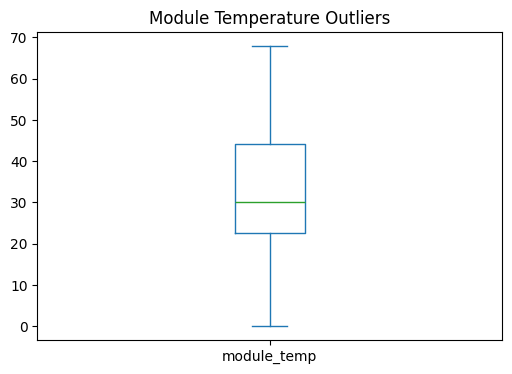

In [ ]:
plt.figure(figsize=(6,4))

df6["module_temp"].plot.box()

plt.title("Module Temperature Outliers")

plt.show()

In [ ]:
df6 = df6.set_index("Timestamp")
df6.index

DatetimeIndex(['2020-06-01 00:00:00', '2020-06-01 00:01:00',
               '2020-06-01 00:02:00', '2020-06-01 00:03:00',
               '2020-06-01 00:04:00', '2020-06-01 00:05:00',
               '2020-06-01 00:06:00', '2020-06-01 00:07:00',
               '2020-06-01 00:08:00', '2020-06-01 00:09:00',
               ...
               '2020-06-30 23:50:00', '2020-06-30 23:51:00',
               '2020-06-30 23:52:00', '2020-06-30 23:53:00',
               '2020-06-30 23:54:00', '2020-06-30 23:55:00',
               '2020-06-30 23:56:00', '2020-06-30 23:57:00',
               '2020-06-30 23:58:00', '2020-06-30 23:59:00'],
              dtype='datetime64[ns]', name='Timestamp', length=43200, freq=None)

#Temperature Over Time

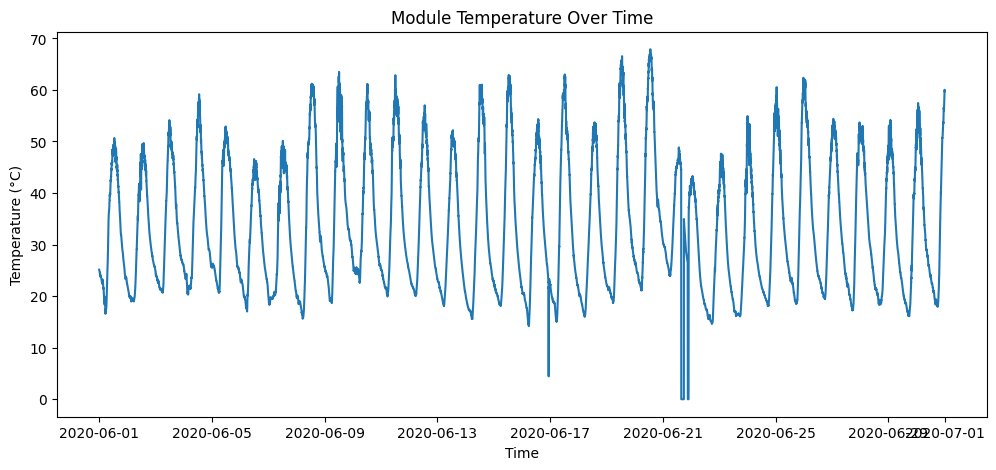

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df6.index, df6["module_temp"])

plt.title("Module Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

Why Temperature Gets So High:
Solar panels heat up because they absorb sunlight.
Important physics concept:
Solar radiation → converted to electricity
Remaining energy → converted to heat
That is why panel temperature can reach 60–70°C, even if air temperature is only 30–35°C.

The module temperature time-series plot shows clear daily cycles across June 2020. Temperatures increase during daytime due to solar radiation and reach peak values between 60°C and 70°C around midday. During nighttime, temperatures decrease to approximately 20°C due to the absence of solar heating. The periodic pattern reflects the natural solar irradiance cycle. A few abrupt drops observed in the dataset may correspond to sensor anomalies or missing measurements.

In [ ]:
df6 = df6.sort_index()

**Hourly Downsampling**

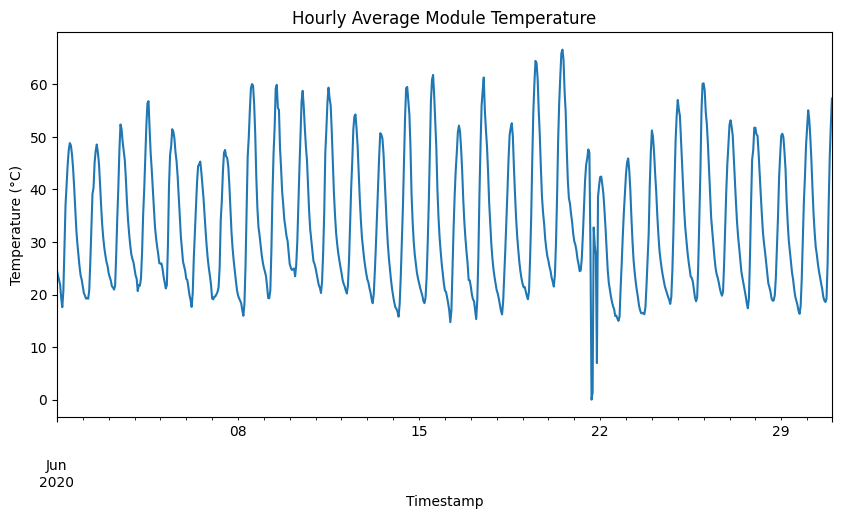

In [ ]:
hourly_temp_june = df6["module_temp"].resample("h").mean()

hourly_temp_june.plot(figsize=(10,5), title="Hourly Average Module Temperature")
plt.ylabel("Temperature (°C)")
plt.show()

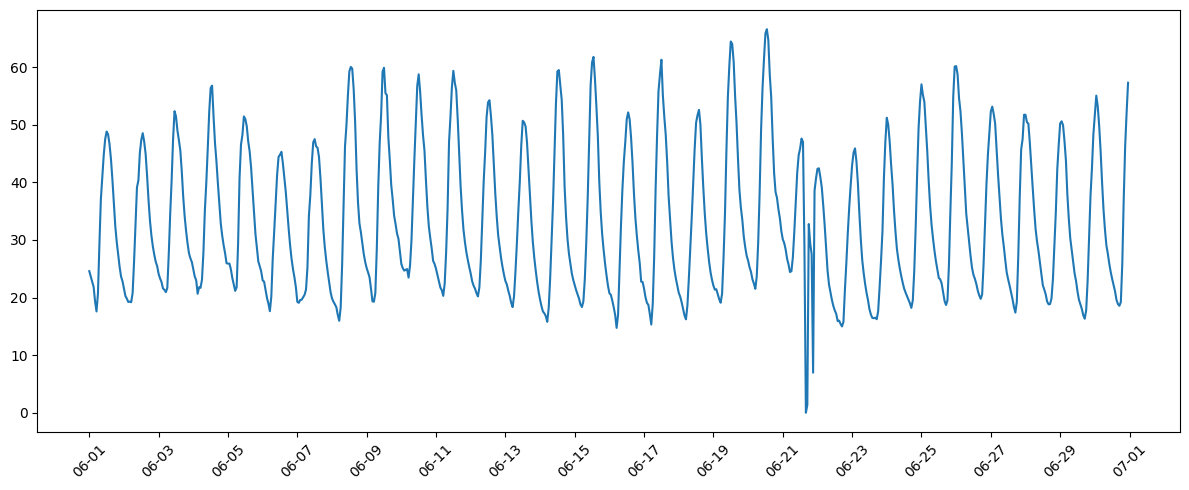

In [ ]:

hourly_temp = df6["module_temp"].resample("h").mean()
plt.figure(figsize=(12,5))
plt.plot(hourly_temp.index, hourly_temp.values)

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) to only show hours of the day


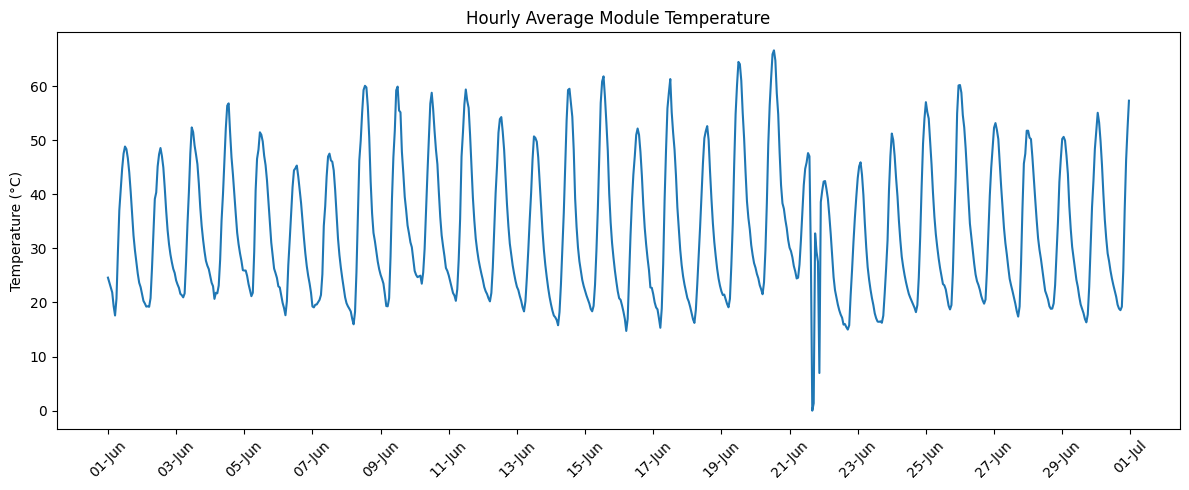

In [ ]:
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))
plt.plot(hourly_temp.index, hourly_temp.values)
plt.title("Hourly Average Module Temperature")
plt.ylabel("Temperature (°C)")

# Set major ticks to every 2 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
# Format the date labels
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

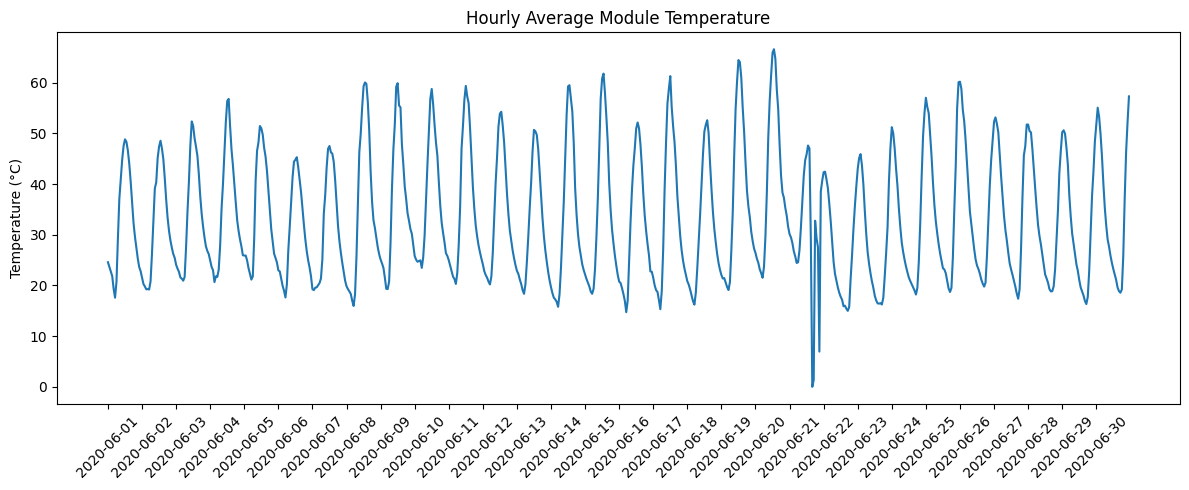

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(hourly_temp.index, hourly_temp.values)
plt.title("Hourly Average Module Temperature")
plt.ylabel("Temperature (°C)")

# Show only every 24th label (once per day)
plt.xticks(hourly_temp.index[::24], rotation=45)

plt.tight_layout()
plt.show()

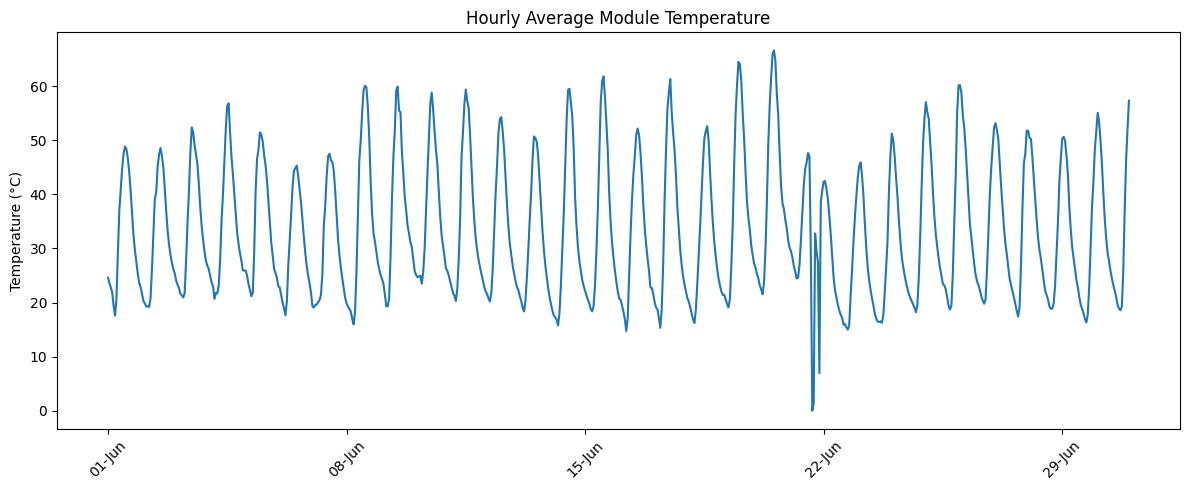

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(hourly_temp.index, hourly_temp.values)
plt.title("Hourly Average Module Temperature")
plt.ylabel("Temperature (°C)")

# Major ticks = every week
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

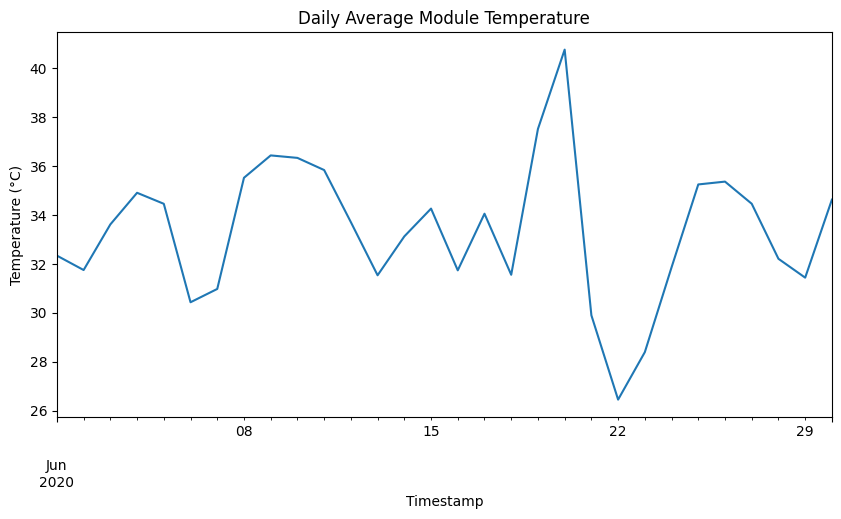

In [ ]:
#daily temp trend
daily_temp = df6["module_temp"].resample("D").mean()

daily_temp.plot(figsize=(10,5), title="Daily Average Module Temperature")
plt.ylabel("Temperature (°C)")
plt.show()

#Irradiance vs Module Temperature

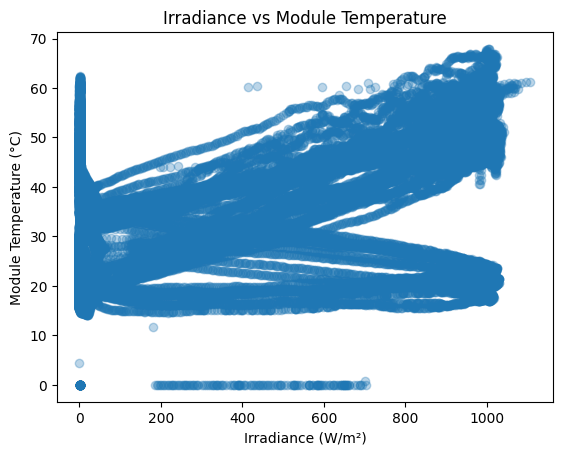

In [ ]:
plt.scatter(df6["irr_sensor_1"], df6["module_temp"], alpha=0.3)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Irradiance vs Module Temperature")

plt.show()

vertical lines at x = 0 -> night time

In [ ]:
df_day = df6[df6['irr_sensor_1'] > 50]   #remove nighttime/very low sunlight

Text(0.5, 1.0, 'Irradiance vs Module Temperature')

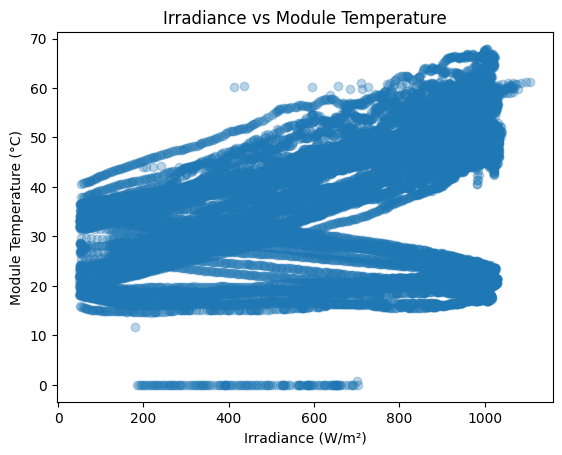

In [ ]:
plt.scatter(df_day['irr_sensor_1'], df_day['module_temp'], alpha=0.3)
plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Irradiance vs Module Temperature")

Text(0.5, 1.0, 'Irradiance vs Module Temperature')

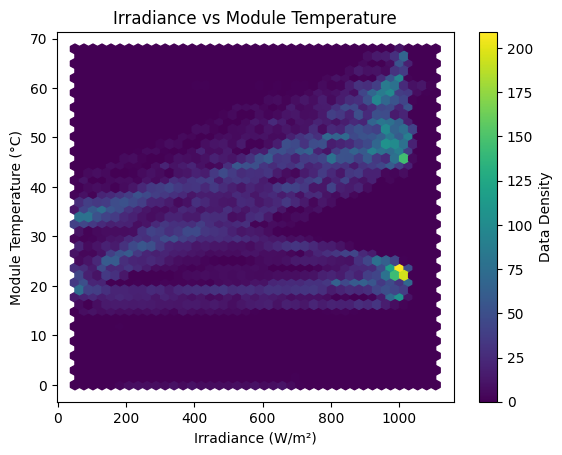

In [ ]:
plt.hexbin(df_day['irr_sensor_1'], df_day['module_temp'], gridsize=40, cmap='viridis')
plt.colorbar(label='Data Density')
plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Irradiance vs Module Temperature")
#hexbin plot instead of scatter to show density

clear upward trend

low irradiance -> lower module temperature
high irradiance -> higher module temperature

**one day (june 15)**

In [ ]:
one_day = df6.loc["2020-06-15"]

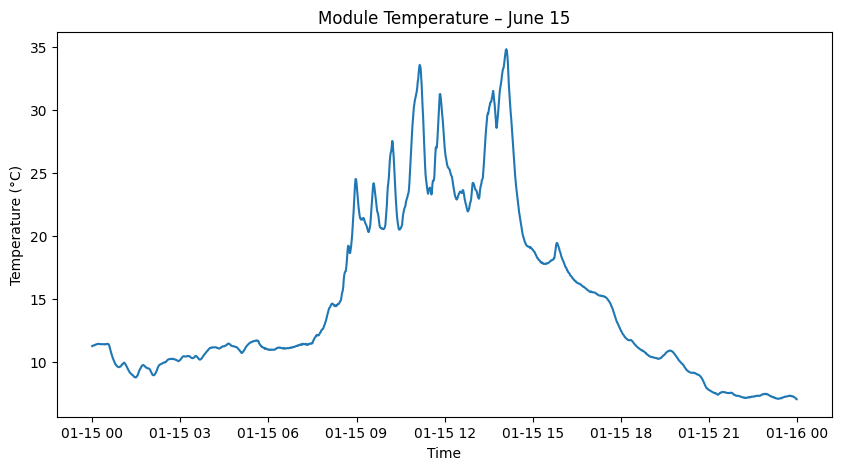

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(one_day.index, one_day["module_temp"])

plt.title("Module Temperature – June 15")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

**one day resampled (10 min averages)**

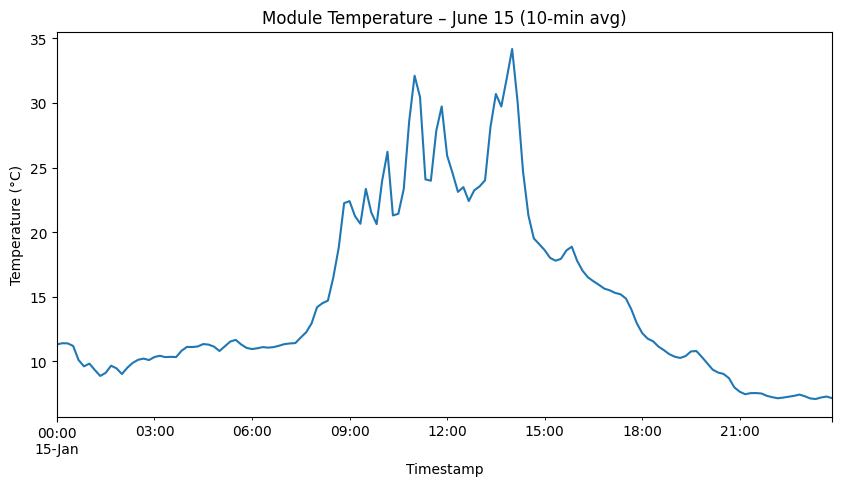

In [ ]:
one_day_resampled = one_day["module_temp"].resample("10min").mean()

one_day_resampled.plot(figsize=(10,5), title="Module Temperature – June 15 (10-min avg)")
plt.ylabel("Temperature (°C)")
plt.show()

In [ ]:
df6["hour"] = df6.index.hour
df6["day"] = df6.index.day

temp_heatmap = df6.pivot_table(
    values="module_temp",
    index="hour",
    columns="day",
    aggfunc="mean"
)

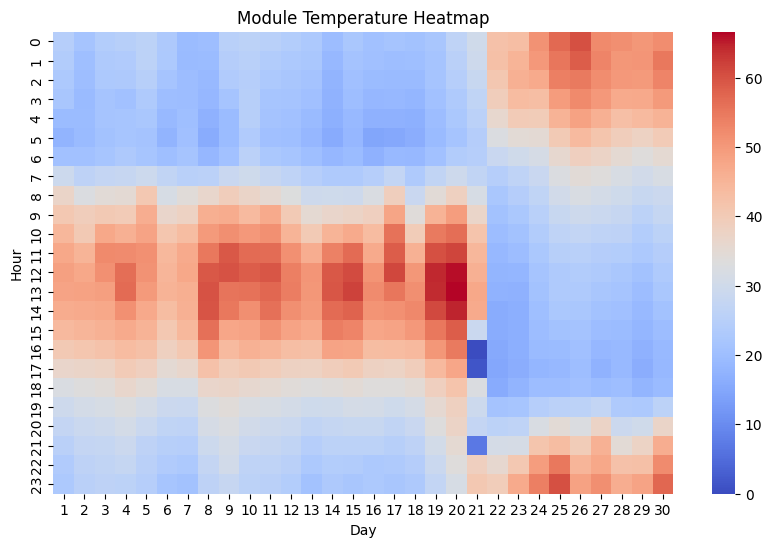

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(temp_heatmap, cmap="coolwarm")

plt.title("Module Temperature Heatmap")
plt.xlabel("Day")
plt.ylabel("Hour")

plt.show()

#Load Dataset (July 2021)

In [ ]:
df7 = pd.read_excel("/content/MEMR-Raw Data-July.xlsx", skiprows=3)

print(df7.shape)
print(df7.columns)

(44640, 22)
Index(['Unnamed: 0', 'Unnamed: 1', '[W/mÂ²]', '[W/mÂ²].1', '[W/mÂ²].2',
       '[W/mÂ²].3', '[W/mÂ²].4', '[W/mÂ²].5', 'Irradiation Tilted (kWh/m2)',
       'Unnamed: 9', 'Generated Yield (kWh)', '[Â°C]',
       'Average Module Temp (C°)', '[kW]', '[kW].1', '[kW].2',
       'Inverter 1 useful time ', 'Inverter 2 useful time ',
       'Inverter 3 useful time ', 'Inverter 1 down time ',
       'Inverter 2 down time ', 'Inverter 3 down time '],
      dtype='object')


#Data Cleaning

In [ ]:
df7.columns = [
    "datetime", "col_unused",
    "irr_sensor_1","irr_sensor_2","irr_sensor_3",
    "irr_sensor_4","irr_sensor_5","irr_sensor_6",
    "irradiation_tilted",
    "power_analyzer","generated_yield",
    "module_temp","avg_module_temp",
    "1","2","30","4","5","6","7","8","9"
][:df7.shape[1]]  #ensure no mismatch

In [ ]:
df7["Timestamp"] = pd.to_datetime(df7["datetime"], dayfirst=True, errors="coerce")
df7 = df7.dropna(subset=["Timestamp"])
df7 = df7.set_index("Timestamp")
df7 = df7.sort_index()

In [ ]:
df7["month"] = df7.index.month
df7["day"] = df7.index.day
df7["hour"] = df7.index.hour

#Temperature Over Time

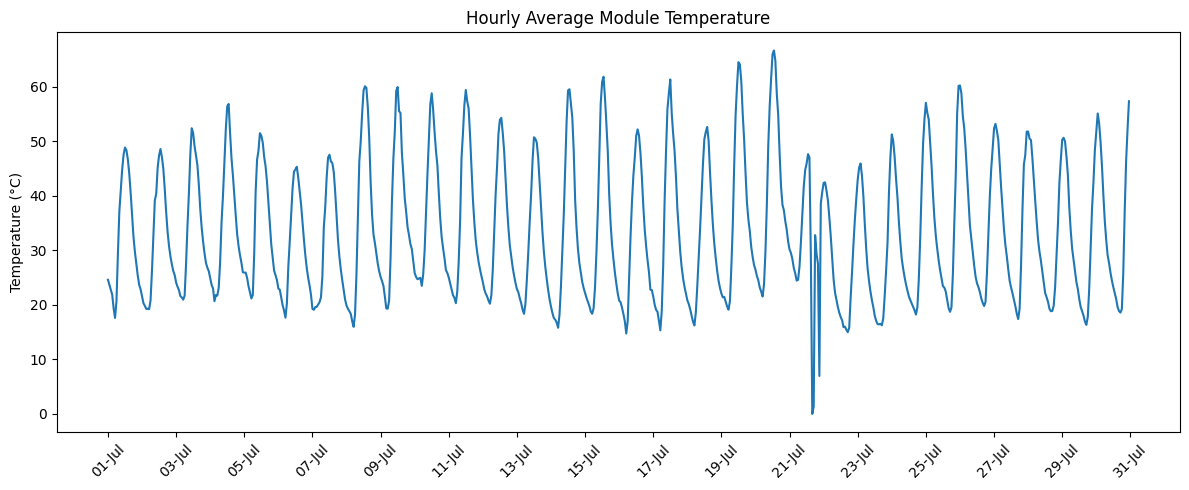

In [ ]:
import matplotlib.dates as mdates
hourly_temp_july = df7["module_temp"].resample("h").mean()

"""hourly_temp_july.plot(figsize=(10,5), title="Hourly Average Module Temperature - July 2020")
plt.ylabel("Temperature (°C)")
plt.show()"""



plt.figure(figsize=(12,5))
plt.plot(hourly_temp_july.index, hourly_temp_july.values)
plt.title("Hourly Average Module Temperature")
plt.ylabel("Temperature (°C)")

# Set major ticks to every 2 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
# Format the date labels
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



One day Resampling (July 7)

In [ ]:
one_day_july = df7.loc["2020-07-15"]

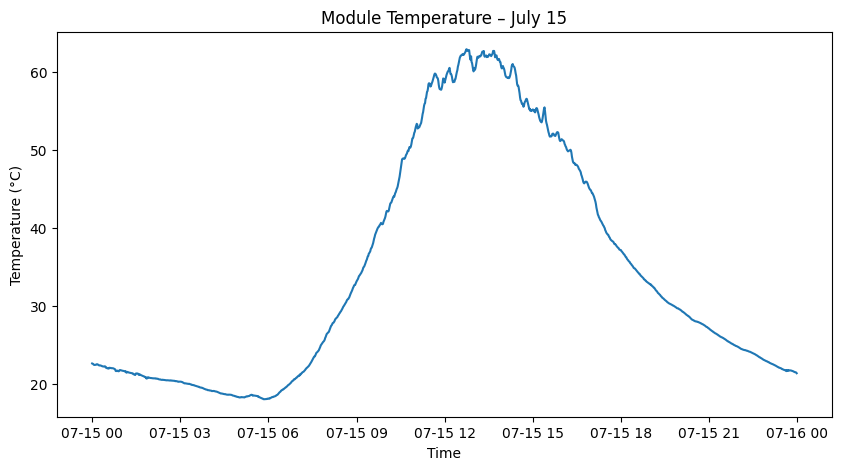

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(one_day_july.index, one_day_july["module_temp"])

plt.title("Module Temperature – July 15")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

**one day resampled (10 min averages)**

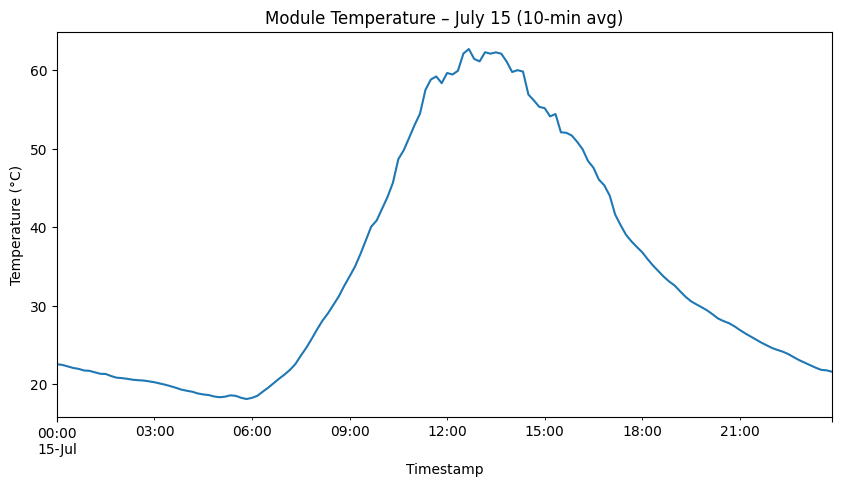

In [ ]:
one_day_resampled_july = one_day_july["module_temp"].resample("10min").mean()

one_day_resampled_july.plot(figsize=(10,5), title="Module Temperature – July 15 (10-min avg)")
plt.ylabel("Temperature (°C)")
plt.show()

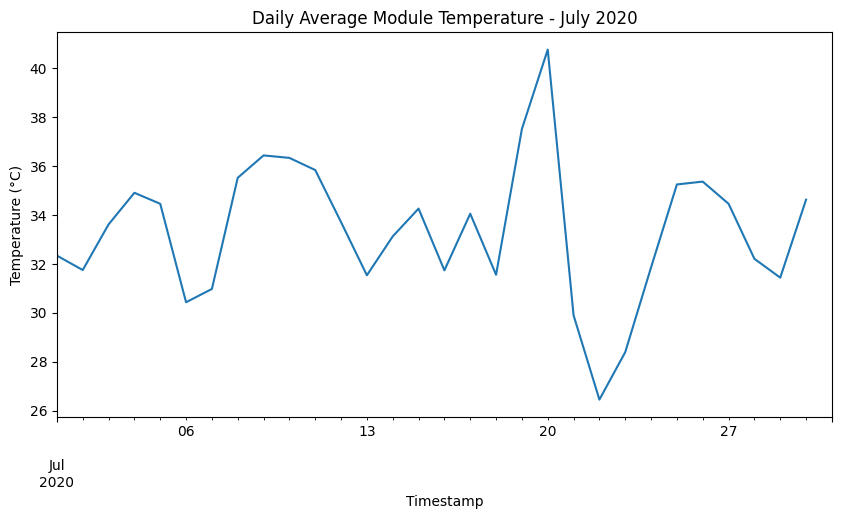

In [ ]:
daily_temp_july = df7["module_temp"].resample("D").mean()
daily_temp_july.plot(figsize=(10,5), title="Daily Average Module Temperature - July 2020")
plt.ylabel("Temperature (°C)")
plt.show()

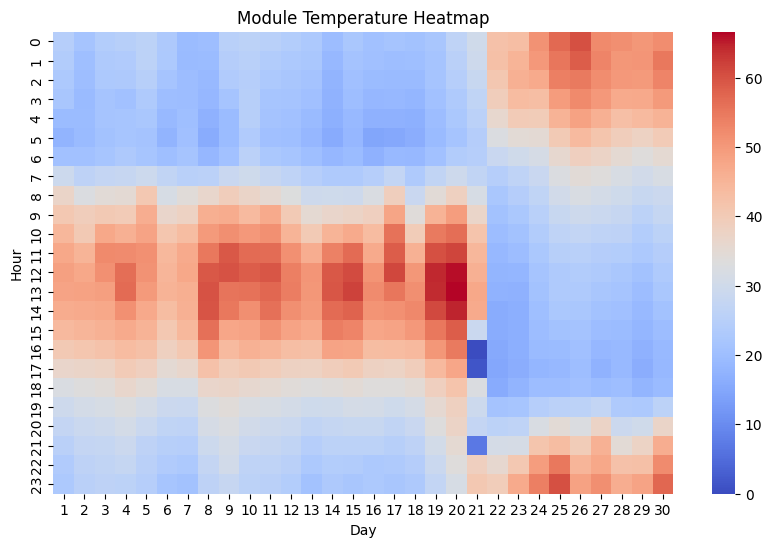

In [ ]:
df7["hour"] = df7.index.hour
df7["day"] = df7.index.day

temp_heatmap = df7.pivot_table(
    values="module_temp",
    index="hour",
    columns="day",
    aggfunc="mean"
)
plt.figure(figsize=(10,6))

sns.heatmap(temp_heatmap, cmap="coolwarm")

plt.title("Module Temperature Heatmap")
plt.xlabel("Day")
plt.ylabel("Hour")

plt.show()

#Irradiance vs Module Temperature

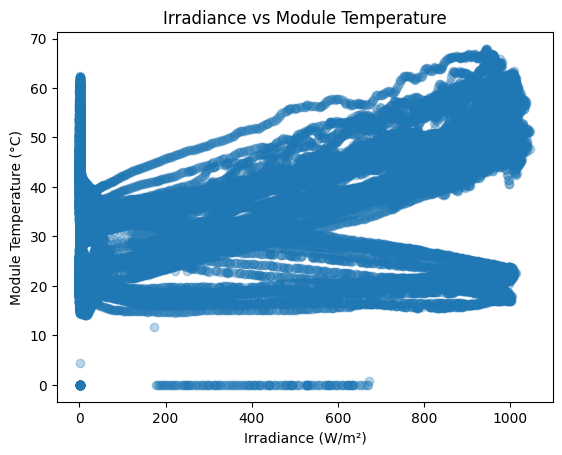

In [ ]:
plt.scatter(df7["irr_sensor_1"], df7["module_temp"], alpha=0.3)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Irradiance vs Module Temperature")

plt.show()

In [ ]:
df_day = df7[df7['irr_sensor_1'] > 50]   #remove nighttime/very low sunlight

Text(0.5, 1.0, 'Irradiance vs Module Temperature')

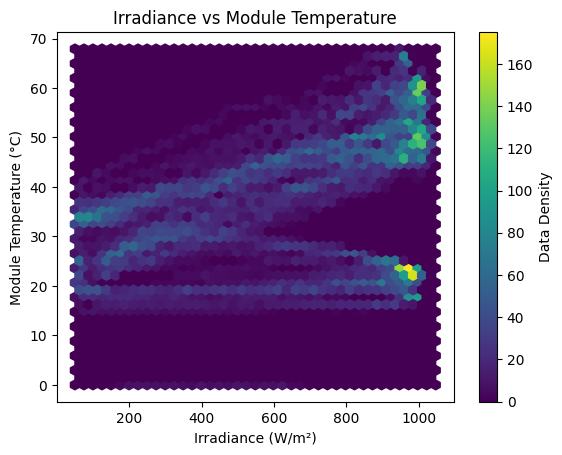

In [ ]:
plt.hexbin(df_day['irr_sensor_1'], df_day['module_temp'], gridsize=40, cmap='viridis')
plt.colorbar(label='Data Density')
plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Irradiance vs Module Temperature")
#hexbin plot instead of scatter to show density

#Load Dataset (January 2021)

In [ ]:
df1 = pd.read_excel(
    "/content/Raw Data January.xlsx",
    skiprows=3
)
print(df1.columns)
df1.head()

Index(['Unnamed: 0', 'Unnamed: 1', '[W/mÂ²]', '[W/mÂ²].1', '[W/mÂ²].2',
       '[W/mÂ²].3', '[W/mÂ²].4', '[W/mÂ²].5', 'Irradiation Tilted (kWh/m2)',
       'Unnamed: 9', 'Generated Yield (kWh)', '[Â°C]',
       'Average Module Temp (C°)', '[kW]', '[kW].1', '[kW].2',
       'Inverter 1 useful time ', 'Inverter 2 useful time ',
       'Inverter 3 useful time ', 'Inverter 1 down time ',
       'Inverter 2 down time ', 'Inverter 3 down time '],
      dtype='object')


,Unnamed: 0,Unnamed: 1,[W/mÂ²],[W/mÂ²].1,[W/mÂ²].2,[W/mÂ²].3,[W/mÂ²].4,[W/mÂ²].5,Irradiation Tilted (kWh/m2),Unnamed: 9,...,Average Module Temp (C°),[kW],[kW].1,[kW].2,Inverter 1 useful time,Inverter 2 useful time,Inverter 3 useful time,Inverter 1 down time,Inverter 2 down time,Inverter 3 down time
0,01.01.2021,00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,,0.0,0.0,0.0,0,0,0,0.916162,0.998605,0.997962
1,01.01.2021,00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,,0.0,0.0,0.0,0,0,0,NaN,NaN,NaN
2,01.01.2021,00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,,0.0,0.0,0.0,0,0,0,NaN,NaN,NaN
3,01.01.2021,00:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,,0.0,0.0,0.0,0,0,0,NaN,NaN,NaN
4,01.01.2021,00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,,0.0,0.0,0.0,0,0,0,NaN,NaN,NaN


#Data Cleaning (January 2021)

In [ ]:
df1.columns = [
    "date",
    "time",
    "irr_sensor_1",
    "irr_sensor_2",
    "irr_sensor_3",
    "irr_sensor_4",
    "irr_sensor_5",
    "irr_sensor_6",
    "irradiation_tilted",
    "power_analyzer",
    "generated_yield",
    "module_temp",
    "avg_module_temp",
    "1",
    "2",
    "30",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
]

df1.columns


Index(['date', 'time', 'irr_sensor_1', 'irr_sensor_2', 'irr_sensor_3',
       'irr_sensor_4', 'irr_sensor_5', 'irr_sensor_6', 'irradiation_tilted',
       'power_analyzer', 'generated_yield', 'module_temp', 'avg_module_temp',
       '1', '2', '30', '4', '5', '6', '7', '8', '9'],
      dtype='object')

In [ ]:
df1["datetime"]

,datetime
Timestamp,
2021-01-01,01.01.2021
2021-01-01,01.01.2021
2021-01-01,01.01.2021
2021-01-01,01.01.2021
2021-01-01,01.01.2021
...,...
2021-01-31,31.01.2021
2021-01-31,31.01.2021
2021-01-31,31.01.2021


In [ ]:
df1["Timestamp"] = pd.to_datetime(
    df1["date"].astype(str) + " " + df1["time"].astype(str),
    dayfirst=True
)

In [ ]:
df1["Timestamp"].head()

,Timestamp
0,2021-01-01 00:00:00
1,2021-01-01 00:01:00
2,2021-01-01 00:02:00
3,2021-01-01 00:03:00
4,2021-01-01 00:04:00


In [ ]:
df1.columns

Index(['date', 'time', 'irr_sensor_1', 'irr_sensor_2', 'irr_sensor_3',
       'irr_sensor_4', 'irr_sensor_5', 'irr_sensor_6', 'irradiation_tilted',
       'power_analyzer', 'generated_yield', 'module_temp', 'avg_module_temp',
       '1', '2', '30', '4', '5', '6', '7', '8', '9', 'Timestamp'],
      dtype='object')

In [ ]:
df1 = df1.dropna(subset=["Timestamp"])

In [ ]:
df1['Timestamp'].isnull().sum()

np.int64(0)

In [ ]:
df1["month"] = df1["Timestamp"].dt.month

In [ ]:
df1["month"].unique()

array([1, 2], dtype=int32)

In [ ]:
df1['Timestamp'].dtype

dtype('<M8[ns]')

In [ ]:
df1['Timestamp'].astype('datetime64[ns]')

,Timestamp
0,2021-01-01 00:00:00
1,2021-01-01 00:01:00
2,2021-01-01 00:02:00
3,2021-01-01 00:03:00
4,2021-01-01 00:04:00
...,...
44636,2021-01-31 23:56:00
44637,2021-01-31 23:57:00
44638,2021-01-31 23:58:00
44639,2021-02-01 23:59:00


In [ ]:
df1 = df1[df1['Timestamp'].dt.month == 1]

In [ ]:
df1['month'].unique()

array([1], dtype=int32)

In [ ]:
df1.shape

(44640, 24)

In [ ]:
df1.head()

,date,time,irr_sensor_1,irr_sensor_2,irr_sensor_3,irr_sensor_4,irr_sensor_5,irr_sensor_6,irradiation_tilted,power_analyzer,...,2,30,4,5,6,7,8,9,Timestamp,month
0,01.01.2021,00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,0.0,0.0,0,0,0,0.916162,0.998605,0.997962,2021-01-01 00:00:00,1
1,01.01.2021,00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,0.0,0.0,0,0,0,NaN,NaN,NaN,2021-01-01 00:01:00,1
2,01.01.2021,00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,0.0,0.0,0,0,0,NaN,NaN,NaN,2021-01-01 00:02:00,1
3,01.01.2021,00:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,0.0,0.0,0,0,0,NaN,NaN,NaN,2021-01-01 00:03:00,1
4,01.01.2021,00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,...,0.0,0.0,0,0,0,NaN,NaN,NaN,2021-01-01 00:04:00,1


In [ ]:
df1["module_temp"].info()

<class 'pandas.core.series.Series'>
Index: 44640 entries, 0 to 44640
Series name: module_temp
Non-Null Count  Dtype  
--------------  -----  
44640 non-null  float64
dtypes: float64(1)
memory usage: 697.5 KB


In [ ]:
df1["module_temp"].describe()

,module_temp
count,44640.000000
mean,14.622884
std,10.194980
min,-2.920000
25%,7.170000
50%,11.410000
75%,21.380000
max,42.660000


In [ ]:
df1['module_temp'].isnull().sum()

np.int64(0)

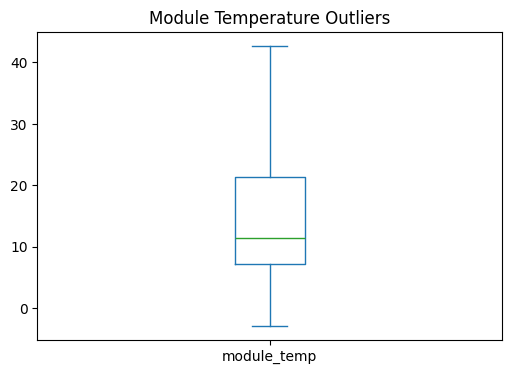

In [ ]:
plt.figure(figsize=(6,4))

df1["module_temp"].plot.box()

plt.title("Module Temperature Outliers")

plt.show()

In [ ]:
df1 = df1.set_index("Timestamp")
df1 = df1.sort_index()
df1.index

DatetimeIndex(['2021-01-01 00:00:00', '2021-01-01 00:00:00',
               '2021-01-01 00:01:00', '2021-01-01 00:02:00',
               '2021-01-01 00:03:00', '2021-01-01 00:04:00',
               '2021-01-01 00:05:00', '2021-01-01 00:06:00',
               '2021-01-01 00:07:00', '2021-01-01 00:08:00',
               ...
               '2021-01-31 23:50:00', '2021-01-31 23:51:00',
               '2021-01-31 23:52:00', '2021-01-31 23:53:00',
               '2021-01-31 23:54:00', '2021-01-31 23:55:00',
               '2021-01-31 23:56:00', '2021-01-31 23:57:00',
               '2021-01-31 23:58:00', '2021-01-31 23:59:00'],
              dtype='datetime64[ns]', name='Timestamp', length=44640, freq=None)

In [ ]:
df1["module_temp"].count()

np.int64(44640)

In [ ]:
len(df1)

44640

In [ ]:
df1["module_temp"].isna().sum()

np.int64(0)

In [ ]:
df1.index.min(), df1.index.max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2021-01-31 23:59:00'))

#Module Temperature Over Time

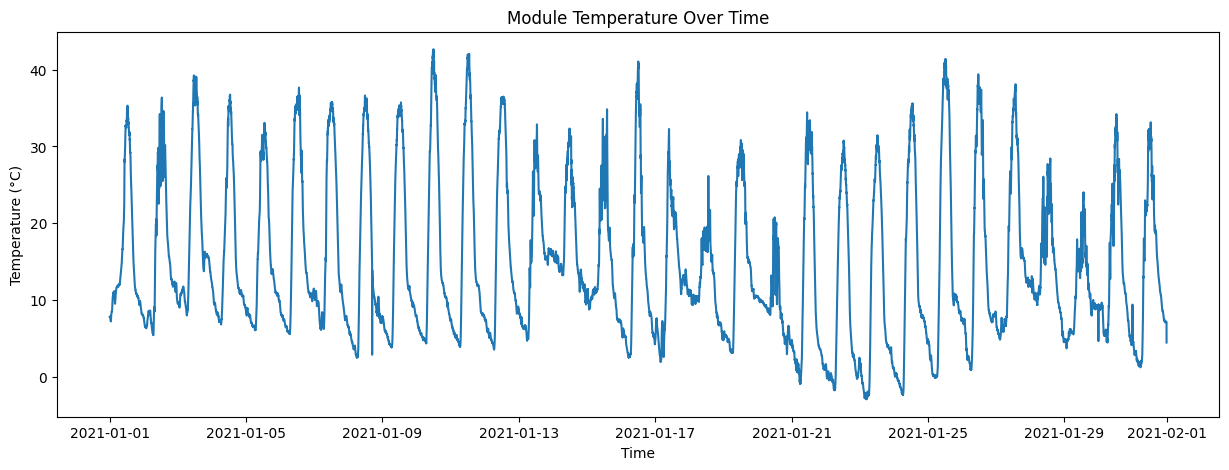

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df1.index, df1["module_temp"])

plt.title("Module Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

**hourly downsampling**

In [ ]:
df1["module_temp"].head(50)

,module_temp
Timestamp,
2021-01-01,7.81
2021-01-01,18.93
2021-01-01,19.01
2021-01-01,19.12
2021-01-01,19.21
2021-01-01,19.33
2021-01-01,19.42
2021-01-01,19.52
2021-01-01,19.63


In [ ]:
hourly_temp_jan = df1["module_temp"].resample("h").mean()
hourly_temp_jan

,module_temp
Timestamp,
2021-01-01 00:00:00,7.578197
2021-01-01 01:00:00,8.731833
2021-01-01 02:00:00,10.761000
2021-01-01 03:00:00,10.372167
2021-01-01 04:00:00,11.232833
...,...
2021-01-31 19:00:00,11.220833
2021-01-31 20:00:00,9.604833
2021-01-31 21:00:00,8.336667


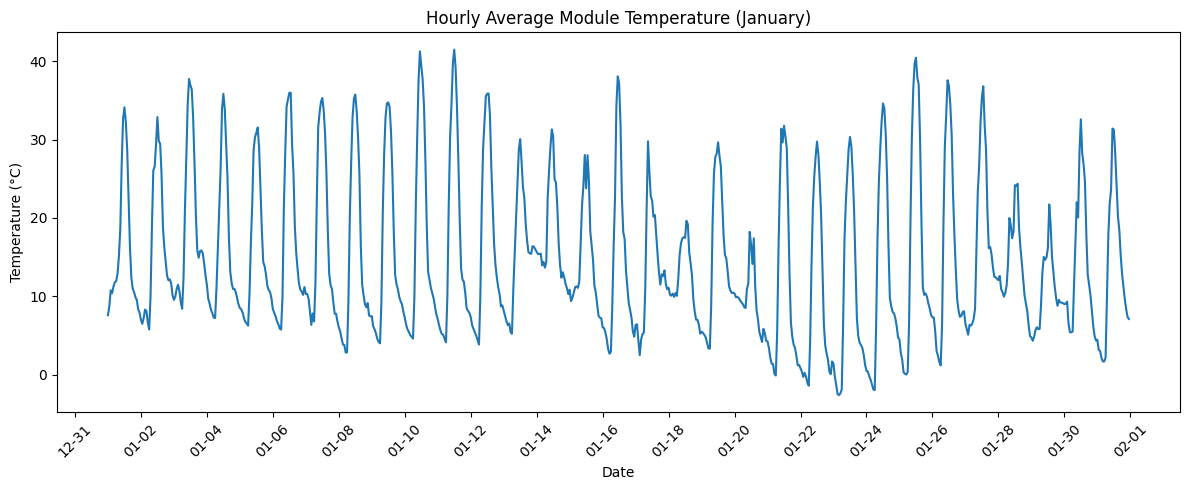

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(hourly_temp_jan.index, hourly_temp_jan.values)

ax = plt.gca()

# show a tick every 2 days
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

# format the date
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.title("Hourly Average Module Temperature (January)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) to only show hours of the day


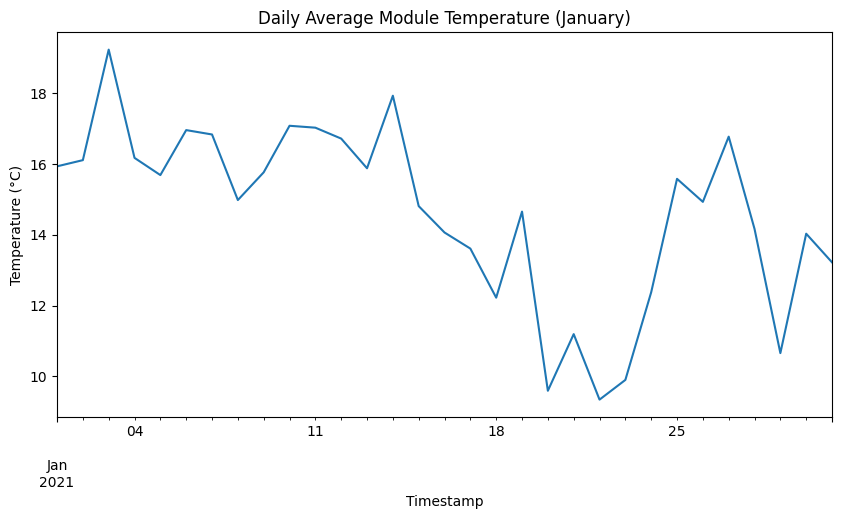

In [ ]:
#daily temp trend
daily_temp_jan = df1["module_temp"].resample("D").mean()

daily_temp_jan.plot(figsize=(10,5), title="Daily Average Module Temperature (January)")
plt.ylabel("Temperature (°C)")
plt.show()

#Irradiance vs Module Temperature

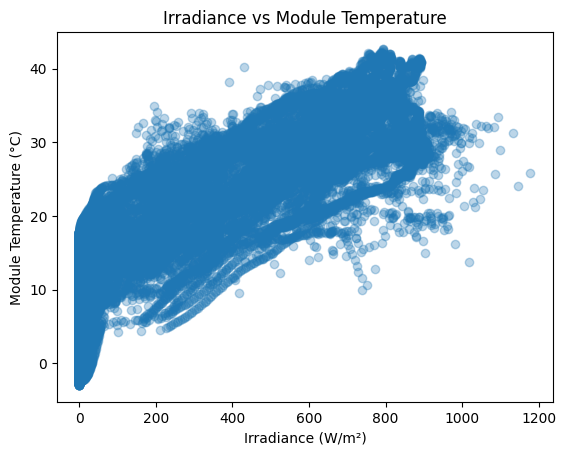

In [ ]:
plt.scatter(df1["irr_sensor_1"], df1["module_temp"], alpha=0.3)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Irradiance vs Module Temperature")

plt.show()

In [ ]:
df_day_jan = df1[df1['irr_sensor_1'] > 50]   #remove nighttime/very low sunlight

Text(0.5, 1.0, 'Irradiance vs Module Temperature')

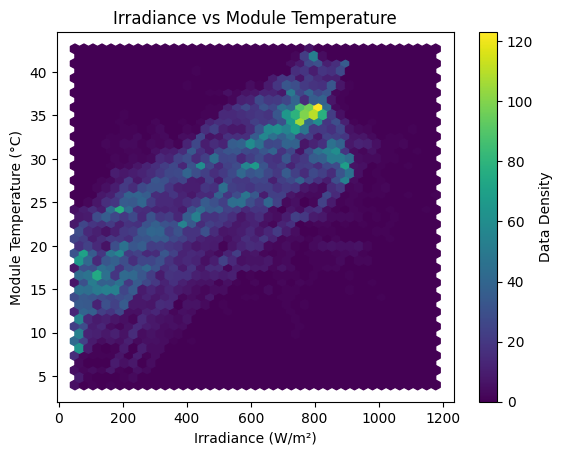

In [ ]:
plt.hexbin(df_day_jan['irr_sensor_1'], df_day_jan['module_temp'], gridsize=40, cmap='viridis')
plt.colorbar(label='Data Density')
plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Irradiance vs Module Temperature")
#hexbin plot instead of scatter to show density

one day resampling

In [ ]:
one_day_jan = df1.loc["2021-01-15"]

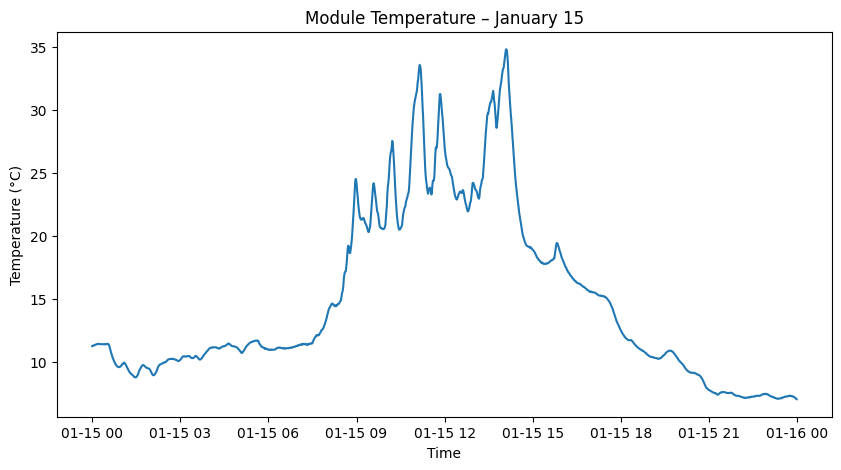

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(one_day_jan.index, one_day_jan["module_temp"])

plt.title("Module Temperature – January 15")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

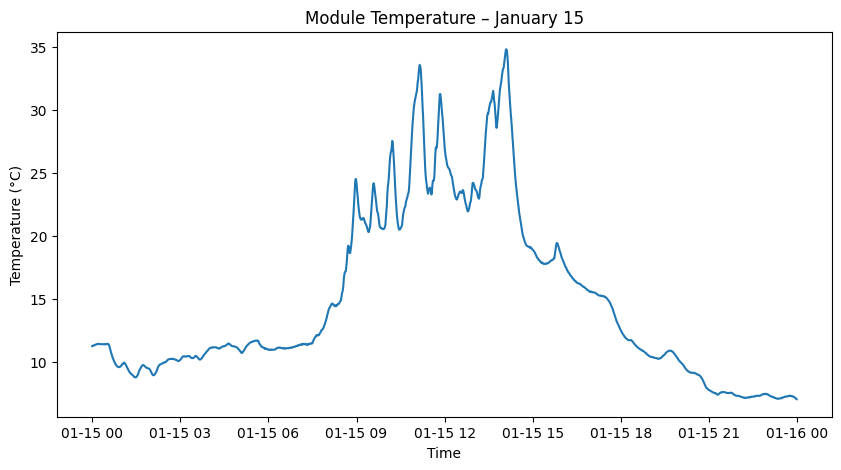

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(one_day_jan.index, one_day_jan["module_temp"])

plt.title("Module Temperature – January 15")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

**one day resampled (10 min averages)**

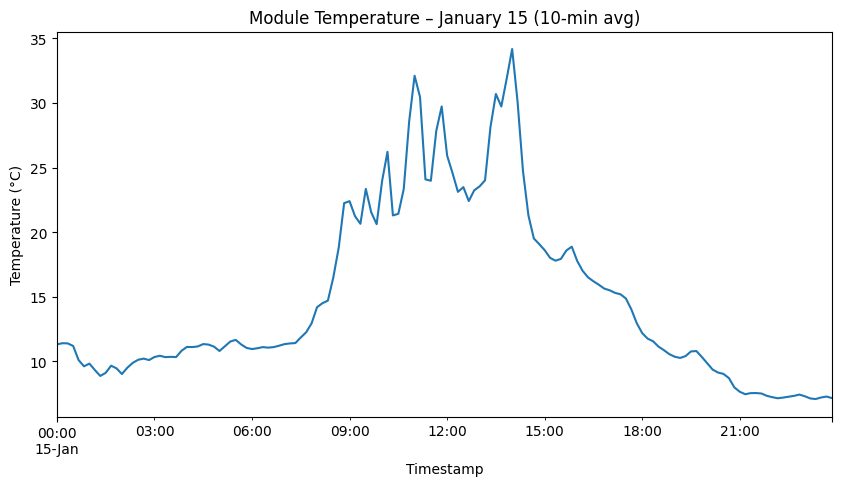

In [ ]:
one_day_resampled_jan = one_day_jan["module_temp"].resample("10min").mean()

one_day_resampled_jan.plot(figsize=(10,5), title="Module Temperature – January 15 (10-min avg)")
plt.ylabel("Temperature (°C)")
plt.show()

#Module Temperature vs Time (Winter vs Summer)

In [ ]:
winter_day = df1.loc["2021-01-15"]
summer_day = df7.loc["2020-07-15"]

In [ ]:
winter_day = winter_day.copy()
summer_day = summer_day.copy()

winter_day["hour"] = winter_day.index.hour + winter_day.index.minute/60
summer_day["hour"] = summer_day.index.hour + summer_day.index.minute/60

In [ ]:
print(winter_day.index.min(), winter_day.index.max())
print(summer_day.index.min(), summer_day.index.max())

2021-01-15 00:00:00 2021-01-15 23:59:00
2020-07-15 00:00:00 2020-07-15 23:59:00


In [ ]:
"""import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(winter_day.index, winter_day["module_temp"], label="Jan 15 (Winter)")
plt.plot(summer_day.index, summer_day["module_temp"], label="Jul 15 (Summer)")

plt.xlabel("Time of Day")
plt.ylabel("Module Temperature (°C)")
plt.title("Module Temperature During Winter vs Summer")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()"""

'import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10,5))\n\nplt.plot(winter_day.index, winter_day["module_temp"], label="Jan 15 (Winter)")\nplt.plot(summer_day.index, summer_day["module_temp"], label="Jul 15 (Summer)")\n\nplt.xlabel("Time of Day")\nplt.ylabel("Module Temperature (°C)")\nplt.title("Module Temperature During Winter vs Summer")\nplt.legend()\n\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()'

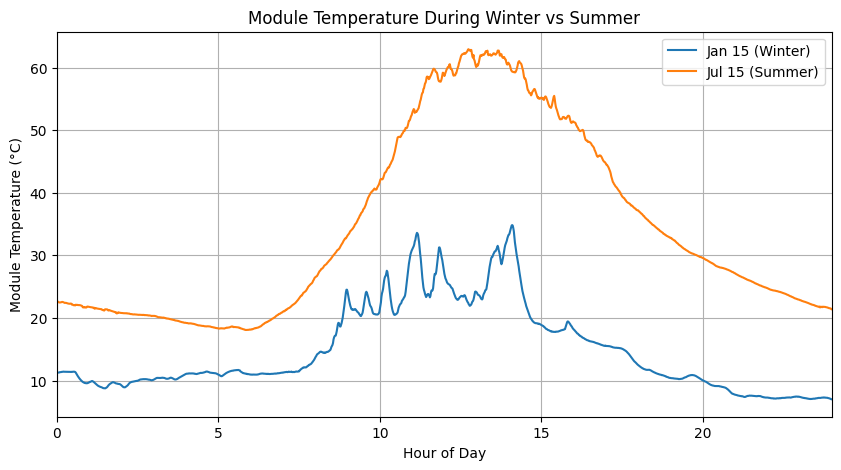

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(winter_day["hour"], winter_day["module_temp"], label="Jan 15 (Winter)")
plt.plot(summer_day["hour"], summer_day["module_temp"], label="Jul 15 (Summer)")

plt.xlabel("Hour of Day")
plt.ylabel("Module Temperature (°C)")
plt.title("Module Temperature During Winter vs Summer")

plt.xlim(0,24)
plt.legend()
plt.grid(True)

plt.show()
#reset the index and explicitly use only the hour of day.

Module temperature follows the solar radiation cycle. In winter, the panel receives less sunlight and the heating period is shorter, leading to lower temperatures. In summer, stronger irradiance increases panel heating and produces higher peak temperatures.

In [ ]:
winter_day["irr_avg"] = winter_day[
["irr_sensor_1","irr_sensor_2","irr_sensor_3",
 "irr_sensor_4","irr_sensor_5","irr_sensor_6"]
].mean(axis=1)

summer_day["irr_avg"] = summer_day[
["irr_sensor_1","irr_sensor_2","irr_sensor_3",
 "irr_sensor_4","irr_sensor_5","irr_sensor_6"]
].mean(axis=1)

In [ ]:
winter_day["hour"] = winter_day.index.hour + winter_day.index.minute/60
summer_day["hour"] = summer_day.index.hour + summer_day.index.minute/60

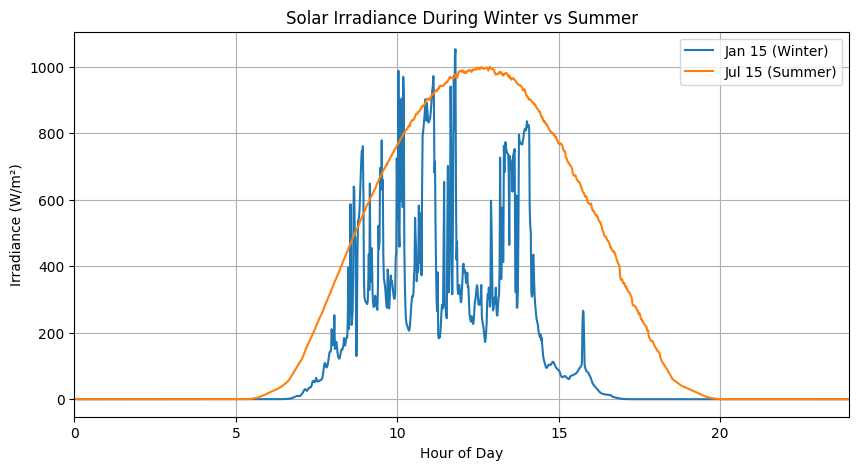

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(winter_day["hour"], winter_day["irr_avg"], label="Jan 15 (Winter)")
plt.plot(summer_day["hour"], summer_day["irr_avg"], label="Jul 15 (Summer)")

plt.xlabel("Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.title("Solar Irradiance During Winter vs Summer")

plt.xlim(0,24)
plt.legend()
plt.grid(True)

plt.show()

The irradiance comparison reveals a clear seasonal difference. Summer days exhibit a smooth bell-shaped irradiance curve with higher peak values and longer daylight duration. In contrast, winter irradiance is lower and more irregular due to cloud cover and reduced solar elevation angles. These variations directly influence the module temperature patterns observed in the PV system.

10 min averages

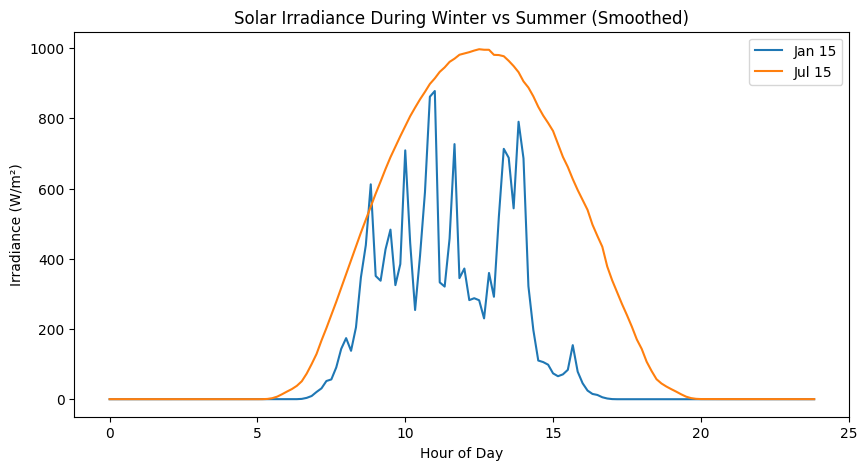

In [ ]:
winter_smooth = winter_day["irr_avg"].resample("10min").mean()
summer_smooth = summer_day["irr_avg"].resample("10min").mean()

plt.figure(figsize=(10,5))

plt.plot(winter_smooth.index.hour + winter_smooth.index.minute/60,
         winter_smooth, label="Jan 15")

plt.plot(summer_smooth.index.hour + summer_smooth.index.minute/60,
         summer_smooth, label="Jul 15")

plt.xlabel("Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.title("Solar Irradiance During Winter vs Summer (Smoothed)")
plt.legend()
plt.show()

#Module vs Irradiance

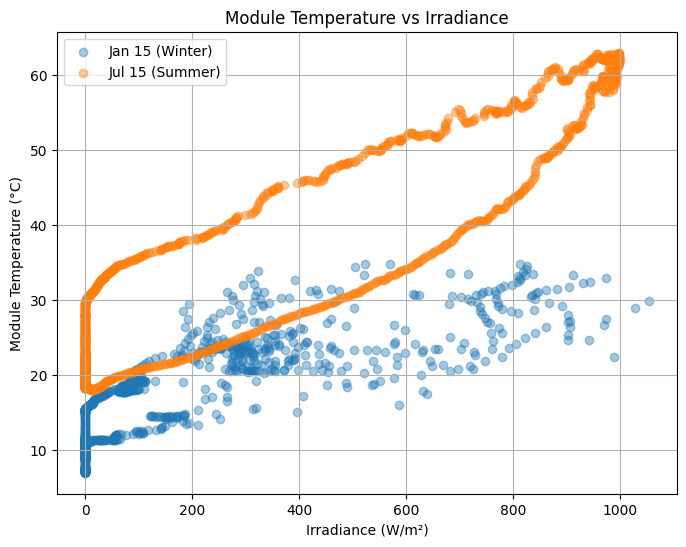

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    winter_day["irr_avg"],
    winter_day["module_temp"],
    alpha=0.4,
    label="Jan 15 (Winter)"
)

plt.scatter(
    summer_day["irr_avg"],
    summer_day["module_temp"],
    alpha=0.4,
    label="Jul 15 (Summer)"
)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Module Temperature vs Irradiance")

plt.legend()
plt.grid(True)

plt.show()

The scatter plot shows a clear positive relationship between solar irradiance and module temperature. As irradiance increases, the photovoltaic modules absorb more solar energy, causing their temperature to rise. Summer data points appear at higher temperature levels compared to winter, reflecting the higher solar radiation and ambient temperatures during summer months.

#removing night values

In [ ]:
winter_scatter = winter_day[winter_day["irr_avg"] > 50]
summer_scatter = summer_day[summer_day["irr_avg"] > 50]

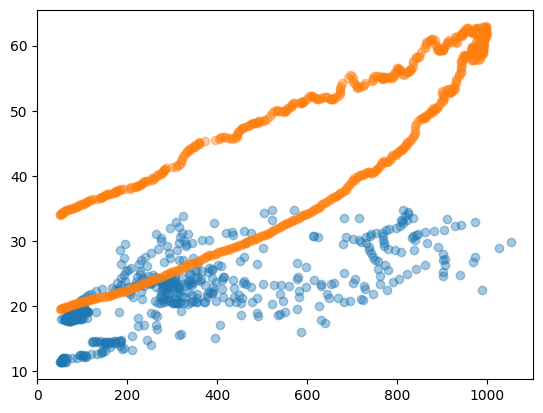

In [ ]:
plt.scatter(winter_scatter["irr_avg"], winter_scatter["module_temp"], alpha=0.4)
plt.scatter(summer_scatter["irr_avg"], summer_scatter["module_temp"], alpha=0.4)

Adding a trend line

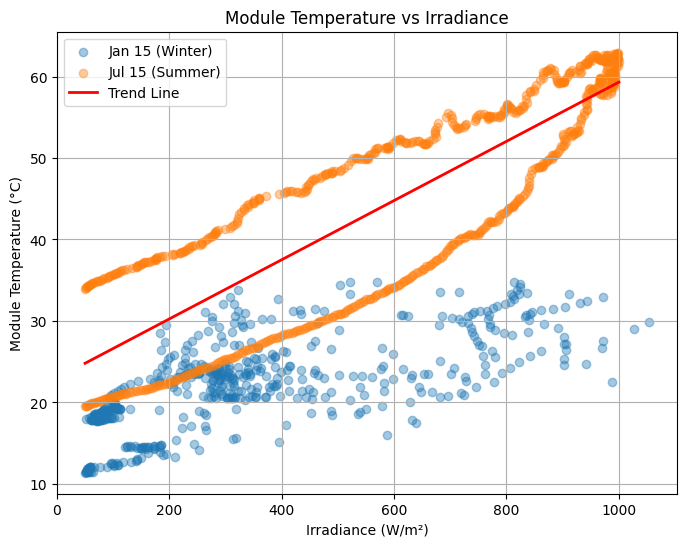

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# scatter plots
plt.scatter(
    winter_scatter["irr_avg"],
    winter_scatter["module_temp"],
    alpha=0.4,
    label="Jan 15 (Winter)"
)

plt.scatter(
    summer_scatter["irr_avg"],
    summer_scatter["module_temp"],
    alpha=0.4,
    label="Jul 15 (Summer)"
)

# trend line
x = summer_scatter["irr_avg"].values
y = summer_scatter["module_temp"].values

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(x_line, trend(x_line), color="red", linewidth=2, label="Trend Line")

# labels
plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module Temperature (°C)")
plt.title("Module Temperature vs Irradiance")

plt.legend()
plt.grid(True)

plt.show()

ignore

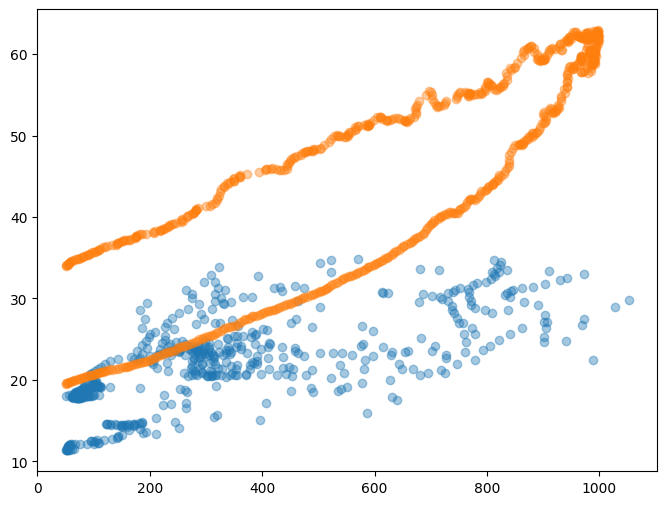

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    winter_scatter["irr_avg"],
    winter_scatter["module_temp"],
    alpha=0.4,
    label="Jan 15 (Winter)"
)

plt.scatter(
    summer_scatter["irr_avg"],
    summer_scatter["module_temp"],
    alpha=0.4,
    label="Jul 15 (Summer)"
)